# Keck LGS tip/tilt & low-bandwidth WFS detector trade study

We are replacing Keck's **STRAP** tip/tilt sensor (TTS) and **Little Joe / CCD39**
low-bandwidth wavefront sensor (LBWFS) in the laser-guide-star AO path. The rest of
the design is already fixed: every candidate runs fast enough for the loop, the
available volume rules out EMCCD/eAPD packages, the relay is the fastest that fits
(f/1.45), and the guide-star spot size is set by the partially-corrected visible
seeing. With optics and spot fixed, the detector is the only free variable, so we
rank candidates by one number — the **centroid measurement error** of the spot, in
milliarcseconds (mas).

The notebook runs the detector physics through the `getframes` API: `Camera.expose`
turns a photon-rate map into a digitised, binned frame (digital or on-chip binning),
`Camera.expose_series` builds the calibration master, and
`getframes.analysis.centroid` runs the calibrated centre-of-gravity. Written by hand
are the Keck-specific inputs: the two-component Gaussian spot model, the KAON
radiometry, and the candidate list.

Order: constraints → spot model → radiometry → candidates → one frame → calibration
→ centroiding → per-magnitude centroid grids → the TTS and LBWFS trades → the pick.

## 1. Setup

The defaults run the full study (400 frames per operating point, the full camera
set, both LBWFS geometries). Drop `TRIALS`, `CALIBRATION_FRAMES`, or thin
`MAGNITUDES` for a faster pass. `TTS_EXAMPLE_CAMERA` / `LBWFS_EXAMPLE_CAMERA` pick
which camera the walkthrough plots use.

In [10]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

import getframes as gf
from getframes.spectral import effective_qe

# --- Monte Carlo budget ----------------------------------------------------
TRIALS = 400  # frames per magnitude / camera / mode
CALIBRATION_FRAMES = 64  # sky+dark frames averaged into each master
CENTROID_THRESHOLD_SIGMA = 1.5
MOTION_POSITIONS = 25  # stratified spot positions across the tracking walk
SEED = 0

MAGNITUDES = np.linspace(10.0, 20.0, 21)  # I-band NGS magnitudes
EXAMPLE_MAGNITUDES = (14.0, 16.0, 18.0)  # rows in the walkthrough centroid grids

# Which camera the walkthrough plots (frame, calibration, centroid grid) use.
TTS_EXAMPLE_CAMERA = "Aries 6504P"
LBWFS_EXAMPLE_CAMERA = "Aries 6504P"

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "image.cmap": "magma",
        "legend.frameon": False,
        "figure.facecolor": "white",
    }
)
COLORS = plt.get_cmap("tab10").colors
print(f"getframes {gf.__version__}  |  {TRIALS} trials/point")

getframes 2.0.0  |  400 trials/point


## 2. Fixed constraints

These describe Keck plus the chosen TTS/LBWFS relay. They are inputs, not free
parameters.

| Quantity | Value | Meaning |
| --- | --- | --- |
| Telescope diameter | 10 m | Keck primary |
| Fried parameter r₀ | 0.15 m @ 0.5 µm | seeing strength |
| AO Strehl | 0.05 @ 0.8 µm | partial visible correction |
| Relay | f/1.45, 13.7 arcsec/mm | fastest that fits the volume |
| TTS field | 4.8 arcsec | common modelled angular field |
| LBWFS sub-aperture field | 4.672 arcsec | 16 px × 0.292 arcsec legacy field |
| Beamsplitter | 0.90 to TTS | 10% of the light feeds the LBWFS |
| Arm bandpass | 600–950 nm | clips the I/Z zero-point bands |

The relay's 13.7 arcsec/mm plate scale ties each camera's angular sampling to its
physical pixel pitch: an 11 µm camera sees 0.15 arcsec/px, a 4 µm camera 0.055
arcsec/px. The angular field is held fixed and the pixel count floats.

In [11]:
WAVELENGTH_M = 0.8e-6
TELESCOPE_DIAMETER_M = 10.0
FRIED_PARAMETER_M = 0.15
SEEING_WAVELENGTH_M = 0.5e-6
AO_STREHL = 0.05
TTS_BEAMSPLITTER = 0.90

TTS_ARCSEC_PER_MM = 13.7  # f/1.45 relay plate scale
TTS_FIELD_ARCSEC = 4.8
LBWFS_FIELD_ARCSEC = 16.0 * 0.292  # 4.672 arcsec
RAD_TO_ARCSEC = 3600.0 * 180.0 / np.pi


def seeing_fwhm_arcsec():
    """Long-exposure atmospheric seeing FWHM (0.98 lambda / r0)."""
    return RAD_TO_ARCSEC * 0.98 * SEEING_WAVELENGTH_M / FRIED_PARAMETER_M


def diffraction_fwhm_arcsec(aperture_diameter_m):
    """Diffraction FWHM (lambda / D) of an aperture, in arcsec."""
    return RAD_TO_ARCSEC * WAVELENGTH_M / aperture_diameter_m


print(f"seeing FWHM         : {seeing_fwhm_arcsec():.3f} arcsec")
print(f"lambda/D  (full 10m): {diffraction_fwhm_arcsec(TELESCOPE_DIAMETER_M) * 1000:.1f} mas")

seeing FWHM         : 0.674 arcsec
lambda/D  (full 10m): 16.5 mas


## 3. The spot model

We use the two-component Gaussian model from the reference study (`OptTTF_sim_v2`):
a bright seeing-limited core with a faint diffraction-limited component,

  spot = S · G(λ/D) + (1 − S) · G(FWHM_seeing),  S = 0.05.

At 0.8 µm the diffraction FWHM is ~16 mas — far below the pixel scale — so at 5%
Strehl the spot is dominated by the ~0.67 arcsec seeing disc; the model just carries
the small coherent term for completeness.

The LBWFS sees a Shack–Hartmann sub-aperture spot: the seeing disc broadened by the
sub-aperture diffraction (λ·mode/D for a mode×mode geometry), added in quadrature,
with no coherent core (S = 0).

In [12]:
_FWHM_TO_SIGMA = 1.0 / (2.0 * np.sqrt(2.0 * np.log(2.0)))


def _gaussian(shape, plate_scale, fwhm_arcsec, offset=(0.0, 0.0)):
    """Normalised 2-D Gaussian of a given angular FWHM, offset in arcsec.

    The width is floored at ~half a pixel so an unresolved component (the ~16 mas
    diffraction core, far below the pixel scale) is represented as a stable
    ~1-pixel blob instead of underflowing to an all-zero, un-normalisable profile.
    """
    height, width = shape
    sigma = max(fwhm_arcsec * _FWHM_TO_SIGMA, 0.5 * plate_scale)
    y = (np.arange(height) - (height - 1) / 2.0) * plate_scale - offset[1]
    x = (np.arange(width) - (width - 1) / 2.0) * plate_scale - offset[0]
    profile = np.exp(-(y[:, None] ** 2 + x[None, :] ** 2) / (2.0 * sigma**2))
    return profile / profile.sum()


def tts_spot(shape, plate_scale, offset=(0.0, 0.0)):
    """Strehl-weighted diffraction + seeing spot for the TTS."""
    dl = _gaussian(shape, plate_scale, diffraction_fwhm_arcsec(TELESCOPE_DIAMETER_M), offset)
    sl = _gaussian(shape, plate_scale, seeing_fwhm_arcsec(), offset)
    spot = AO_STREHL * dl + (1.0 - AO_STREHL) * sl
    return spot / spot.sum()


def lbwfs_spot(mode, shape, plate_scale, offset=(0.0, 0.0)):
    """Seeing disc broadened by one sub-aperture's diffraction (quadrature FWHM)."""
    fwhm = np.hypot(seeing_fwhm_arcsec(), diffraction_fwhm_arcsec(TELESCOPE_DIAMETER_M / mode))
    return _gaussian(shape, plate_scale, fwhm, offset)

TTS FWHM ~ 0.67 arcsec (seeing-dominated at 5% Strehl)


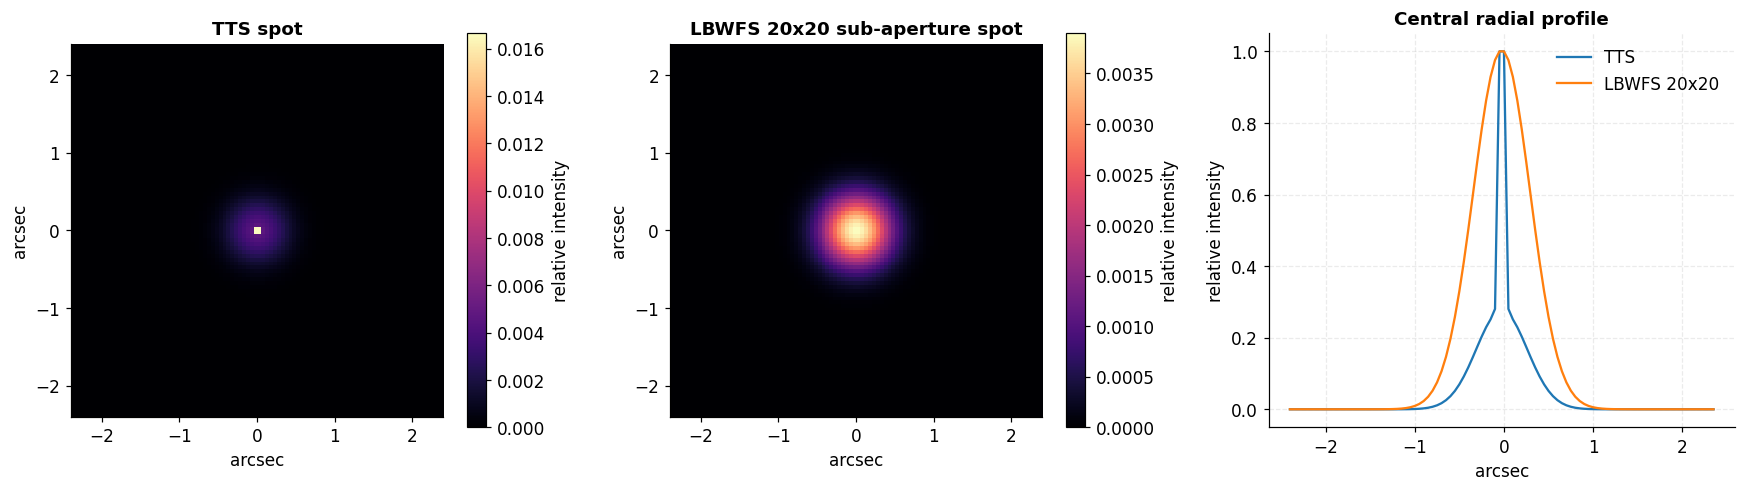

In [13]:
# The two spots on a common 4.8 arcsec field.
scale = 0.05
n = int(np.ceil(TTS_FIELD_ARCSEC / scale))
tts_demo = tts_spot((n, n), scale)
lb_demo = lbwfs_spot(20, (n, n), scale)


def _extent(shape, s):
    height, width = shape
    return (-width * s / 2, width * s / 2, -height * s / 2, height * s / 2)


fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, img, title in (
    (axes[0], tts_demo, "TTS spot"),
    (axes[1], lb_demo, "LBWFS 20x20 sub-aperture spot"),
):
    im = ax.imshow(img, origin="lower", extent=_extent(img.shape, scale))
    fig.colorbar(im, ax=ax, label="relative intensity")
    ax.set(title=title, xlabel="arcsec", ylabel="arcsec")
    ax.grid(False)
r = np.arange(n) * scale - TTS_FIELD_ARCSEC / 2
axes[2].plot(r, tts_demo[n // 2] / tts_demo.max(), color=COLORS[0], label="TTS")
axes[2].plot(r, lb_demo[n // 2] / lb_demo.max(), color=COLORS[1], label="LBWFS 20x20")
axes[2].set(title="Central radial profile", xlabel="arcsec", ylabel="relative intensity")
axes[2].legend()
fig.tight_layout()
print(f"TTS FWHM ~ {seeing_fwhm_arcsec():.2f} arcsec (seeing-dominated at 5% Strehl)")

## 4. Radiometry

The electron rate a camera collects from an I-magnitude star (and the sky) comes
from the KAON 764 / DAVINCI I- and Z-band zero points and sky brightnesses. Three
steps:

1. The zero points were defined at 70% QE, so divide by 0.70 to recover the photon
   rate incident on the detector.
2. The TTS/LBWFS arm passes only 600–950 nm, so keep the fraction of each band that
   falls inside it (weighted by the source spectrum).
3. Fold each camera's wavelength-resolved QE curve through the bands, weighting the
   star by a 3500 K blackbody (M-dwarf-like NGS) and the airglow sky by a flat
   spectrum. Cameras without a QE curve fall back to their scalar QE.

In [14]:
IZ_ZEROPOINT_MAG = np.array([27.34, 27.16])
IZ_SKY_MAG_ARCSEC2 = np.array([19.33, 18.45])
ZEROPOINT_REFERENCE_QE = 0.70
TTF_BANDPASS_NM = (600.0, 950.0)
IZ_BAND_NM = ((700.0, 854.0), (855.0, 962.0))

DEFAULT_NGS_TEFF_K = 3500.0
SKY_WEIGHTING_SED = gf.SED.flat(700.0, 962.0)
NGS_SED = gf.SED.blackbody(DEFAULT_NGS_TEFF_K, 700.0, 962.0)


def _clipped_response(lo, hi):
    lo = max(lo, TTF_BANDPASS_NM[0])
    hi = min(hi, TTF_BANDPASS_NM[1])
    return gf.SpectralBandpass.tophat(center_nm=(lo + hi) / 2.0, width_nm=hi - lo)


IZ_RESPONSES = tuple(_clipped_response(lo, hi) for lo, hi in IZ_BAND_NM)


def incident_star_rates(magnitude):
    """I- and Z-band photons/s at the detector entrance for an I=mag star."""
    return 10.0 ** (-0.4 * (magnitude - IZ_ZEROPOINT_MAG)) / ZEROPOINT_REFERENCE_QE


def incident_sky_rates():
    """I- and Z-band sky photons/s/arcsec^2 at the detector entrance."""
    return 10.0 ** (-0.4 * (IZ_SKY_MAG_ARCSEC2 - IZ_ZEROPOINT_MAG)) / ZEROPOINT_REFERENCE_QE


def iz_effective_qe(camera, weighting_sed):
    """Photon-weighted I/Z QE, using the preset QE curve when available."""
    curve = camera.config.qe_curve
    if curve is None:
        return np.full(2, camera.config.quantum_efficiency, dtype=np.float64)
    return np.array([effective_qe(curve, resp, weighting_sed) for resp in IZ_RESPONSES])


def band_fractions(weighting_sed):
    """Fraction of each zero-point band's photons the 600-950 nm arm passes."""
    fractions = np.empty(2)
    for i, (lo, hi) in enumerate(IZ_BAND_NM):
        grid = np.linspace(lo, hi, 513)
        weight = weighting_sed(grid)
        passed = weight * ((grid >= TTF_BANDPASS_NM[0]) & (grid <= TTF_BANDPASS_NM[1]))
        fractions[i] = float(passed.sum() / weight.sum())
    return fractions


def band_response(camera, weighting_sed):
    """Zero-point photon rate -> detected electron rate, per band."""
    return iz_effective_qe(camera, weighting_sed) * band_fractions(weighting_sed)

The QE curves, source spectra, and what the star looks like once folded through the
arm bandpass and a detector's QE:

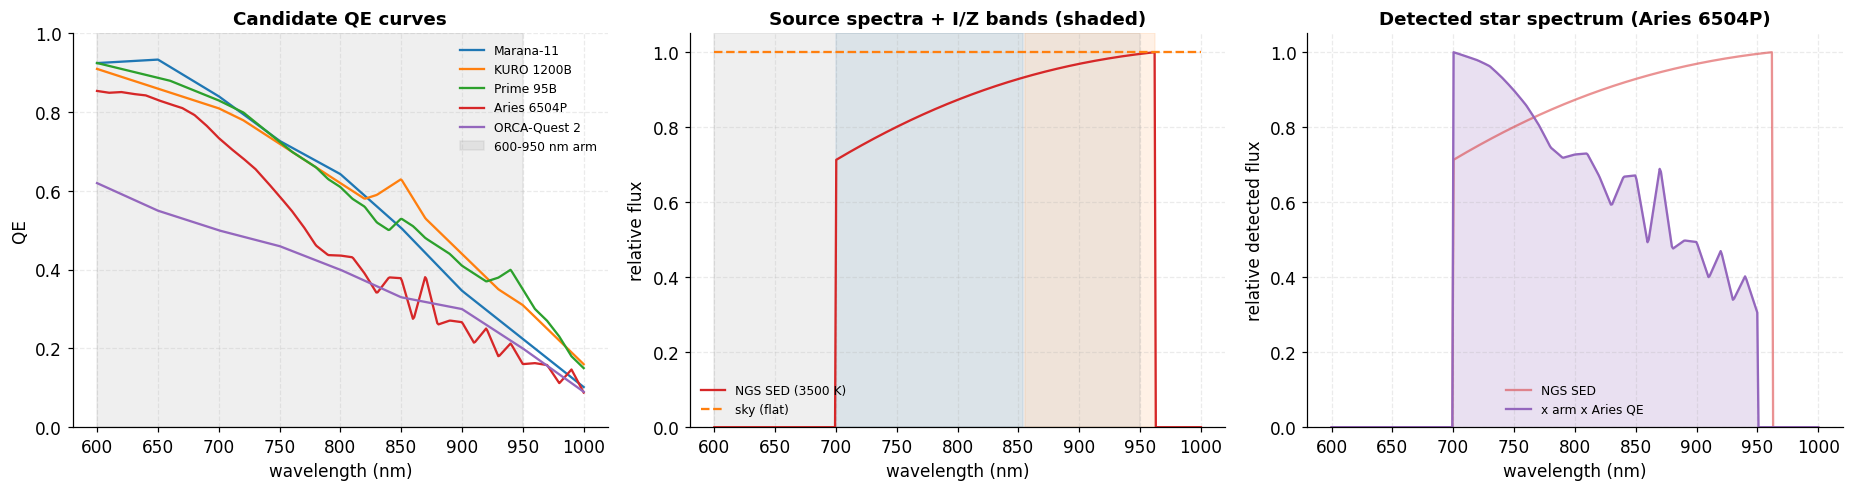

In [15]:
grid = np.linspace(600.0, 1000.0, 400)
qe_presets = [
    ("andor_marana_4_2b_11", "Marana-11"),
    ("princeton_instruments_kuro_1200b", "KURO 1200B"),
    ("photometrics_prime_95b", "Prime 95B"),
    ("tucsen_aries_6504_pro", "Aries 6504P"),
    ("hamamatsu_orca_quest_2", "ORCA-Quest 2"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) Candidate QE curves.
for i, (slug, label) in enumerate(qe_presets):
    curve = gf.load_preset(slug).qe_curve
    if curve is not None:
        axes[0].plot(grid, curve(grid), color=COLORS[i], label=label)
axes[0].axvspan(*TTF_BANDPASS_NM, color="grey", alpha=0.12, label="600-950 nm arm")
axes[0].set(title="Candidate QE curves", xlabel="wavelength (nm)", ylabel="QE", ylim=(0, 1))
axes[0].legend(fontsize=8)

# (b) Source spectra and the arm / band structure.
ngs = NGS_SED(grid) / NGS_SED(grid).max()
sky = SKY_WEIGHTING_SED(np.clip(grid, 700.0, 962.0))
axes[1].plot(grid, ngs, color=COLORS[3], label="NGS SED (3500 K)")
axes[1].plot(grid, sky / sky.max(), color=COLORS[1], ls="--", label="sky (flat)")
for k, (lo, hi) in enumerate(IZ_BAND_NM):
    axes[1].axvspan(lo, hi, color=COLORS[k], alpha=0.10)
axes[1].axvspan(*TTF_BANDPASS_NM, color="grey", alpha=0.12)
axes[1].set(
    title="Source spectra + I/Z bands (shaded)",
    xlabel="wavelength (nm)",
    ylabel="relative flux",
    ylim=(0, 1.05),
)
axes[1].legend(fontsize=8)

# (c) The star folded through the arm and one camera's QE.
arm = ((grid >= TTF_BANDPASS_NM[0]) & (grid <= TTF_BANDPASS_NM[1])).astype(float)
aries_qe = gf.load_preset("tucsen_aries_6504_pro").qe_curve(grid)
detected = NGS_SED(grid) * arm * aries_qe
axes[2].plot(grid, NGS_SED(grid) / NGS_SED(grid).max(), color=COLORS[3], alpha=0.5, label="NGS SED")
axes[2].plot(grid, detected / detected.max(), color=COLORS[4], label="x arm x Aries QE")
axes[2].fill_between(grid, detected / detected.max(), color=COLORS[4], alpha=0.2)
axes[2].set(
    title="Detected star spectrum (Aries 6504P)",
    xlabel="wavelength (nm)",
    ylabel="relative detected flux",
    ylim=(0, 1.05),
)
axes[2].legend(fontsize=8)
fig.tight_layout()

## 5. Candidates and modes

The candidates are the realizable CMOS/sCMOS/CCD packages that fit the volume; all
of them are considered for **both** channels. The 120×120 mm envelope excludes every
EMCCD/eAPD package (NüVü HNü, OCAM2K), so those ship with getframes but are not
ranked here. STRAP and Little Joe are the incumbents to beat.

Binning is now a first-class part of each preset: `config.supported_binnings` (the
factors the sensor offers) and `config.binning_method` (`"digital"` post-read or
`"on_chip"` charge-domain). A camera with more than one read-noise operating point
carries the alternates in `config.extra["read_modes"]` (e.g. ORCA-Quest
standard/ultra-quiet, Aries sensitive/speed). We enumerate one candidate per read
mode × supported binning; the binned read noise comes from the model, not a table.

In [16]:
@dataclass(frozen=True)
class DetectorCandidate:
    preset: str
    label: str
    include: bool = True  # realizable in the available volume (both channels)


@dataclass(frozen=True)
class DetectorMode:
    candidate: DetectorCandidate
    name: str
    binning: int
    binning_method: str  # "digital" (post-read) or "on_chip" (charge-domain)
    read_noise_e: float
    dark_current_e_per_s: float
    temperature_c: float

    @property
    def label(self):
        return f"{self.candidate.label} ({self.name})"


@dataclass(frozen=True)
class SampledMode:
    """A detector mode sampled at native pitch, with optional digital binning."""

    detector_mode: DetectorMode
    camera: gf.Camera
    native_plate_scale: float
    output_plate_scale: float
    native_shape: tuple
    output_shape: tuple

    @property
    def label(self):
        return self.detector_mode.label


CANDIDATES = (
    DetectorCandidate("andor_marana_4_2b_11", "Marana-11"),
    DetectorCandidate("princeton_instruments_kuro_1200b", "KURO 1200B"),
    DetectorCandidate("photometrics_prime_95b", "Prime 95B"),
    DetectorCandidate("qhy530_pro_ii", "QHY530"),
    DetectorCandidate("tucsen_aries_6504_pro", "Aries 6504P"),
    DetectorCandidate("hamamatsu_orca_quest_2", "ORCA-Quest 2"),
    DetectorCandidate("andor_cb1_0_5mp", "CB1 0.5 MP"),
    DetectorCandidate("nuvu_hnu_240", "HNu 240", False),  # EMCCD: no space
    DetectorCandidate("nuvu_hnu_128_omega", "HNu 128", False),  # EMCCD: no space
    DetectorCandidate("andor_ocam2k", "OCAM2K", False),  # EMCCD: no space
)
REALIZABLE = tuple(c for c in CANDIDATES if c.include)


def relay_plate_scale(camera):
    """Native angular pixel scale (arcsec/pixel) at the fixed f/1.45 relay."""
    return camera.config.pixel_size_um * TTS_ARCSEC_PER_MM / 1000.0


def shape_for_field(field_arcsec, plate_scale):
    """Even-pixel ROI retaining a specified common angular field."""
    pixels = int(np.ceil(field_arcsec / plate_scale))
    pixels += pixels % 2
    return (pixels, pixels)


def read_modes_of(config):
    """Normalize config read modes and their allowed binning factors."""
    default_binnings = tuple(int(b) for b in config.supported_binnings)
    raw_modes = config.extra.get("read_modes") or ({},)
    modes = []
    for raw in raw_modes:
        binnings = tuple(int(b) for b in raw.get("supported_binnings", default_binnings))
        invalid = tuple(b for b in binnings if b not in default_binnings)
        if invalid:
            raise ValueError(
                f"{config.name} read mode {raw.get('name', '')!r} includes unsupported "
                f"binning factors {invalid}; config supports {default_binnings}."
            )
        modes.append(
            (
                str(raw.get("name", "")).strip(),
                float(raw.get("read_noise_e", config.read_noise_e)),
                float(raw.get("dark_current_e_per_s", config.dark_current_e_per_s)),
                float(raw.get("temperature_c", config.dark_current_ref_temp_c)),
                binnings,
            )
        )
    return tuple(modes)


def detector_modes(candidates):
    """Enumerate one DetectorMode per read mode x supported binning of each preset."""
    modes = []
    for candidate in candidates:
        config = gf.load_preset(candidate.preset)
        for name, read_noise_e, dark, temp, binnings in read_modes_of(config):
            for binning in binnings:
                tag = f"{name} {binning}x{binning}".strip()
                modes.append(
                    DetectorMode(
                        candidate=candidate,
                        name=tag,
                        binning=binning,
                        binning_method=config.binning_method,
                        read_noise_e=read_noise_e,
                        dark_current_e_per_s=dark,
                        temperature_c=temp,
                    )
                )
    return tuple(modes)


def mode_camera(detector_mode, native_shape):
    """A Camera at native pixels carrying this mode's documented noise."""
    config = gf.load_preset(detector_mode.candidate.preset).replace(
        resolution=native_shape,
        read_noise_e=detector_mode.read_noise_e,
        dark_current_e_per_s=detector_mode.dark_current_e_per_s,
        dark_current_ref_temp_c=detector_mode.temperature_c,
    )
    return gf.Camera(config, default_temperature_c=detector_mode.temperature_c)


def sampled_mode(detector_mode, field_arcsec):
    """Build a native-pixel simulation and its documented output geometry."""
    base = gf.Camera(gf.load_preset(detector_mode.candidate.preset))
    native_scale = relay_plate_scale(base)
    output_scale = native_scale * detector_mode.binning
    output_shape = shape_for_field(field_arcsec, output_scale)
    native_shape = tuple(s * detector_mode.binning for s in output_shape)
    return SampledMode(
        detector_mode,
        mode_camera(detector_mode, native_shape),
        native_scale,
        output_scale,
        native_shape,
        output_shape,
    )

In [17]:
modes = detector_modes(REALIZABLE)
print(f"{'mode':<40}{'pitch':>9}{'scale':>12}{'ROI':>12}")
for m in modes:
    s = sampled_mode(m, TTS_FIELD_ARCSEC)
    pitch = s.camera.config.pixel_size_um * m.binning
    print(f'{s.label:<40}{pitch:6.2f} um{s.output_plate_scale:8.3f}"/px{s.output_shape!s:>12}')

mode                                        pitch       scale         ROI
Marana-11 (1x1)                          11.00 um   0.151"/px    (32, 32)
Marana-11 (2x2)                          22.00 um   0.301"/px    (16, 16)
Marana-11 (3x3)                          33.00 um   0.452"/px    (12, 12)
Marana-11 (4x4)                          44.00 um   0.603"/px      (8, 8)
Marana-11 (8x8)                          88.00 um   1.206"/px      (4, 4)
KURO 1200B (1x1)                         11.00 um   0.151"/px    (32, 32)
KURO 1200B (2x2)                         22.00 um   0.301"/px    (16, 16)
KURO 1200B (4x4)                         44.00 um   0.603"/px      (8, 8)
Prime 95B (1x1)                          11.00 um   0.151"/px    (32, 32)
Prime 95B (2x2)                          22.00 um   0.301"/px    (16, 16)
QHY530 (1x1)                              2.74 um   0.038"/px  (128, 128)
QHY530 (2x2)                              5.48 um   0.075"/px    (64, 64)
Aries 6504P (sensitive 1x1)           

## 6. One frame

The detector step is a single API call — `camera.expose` takes the native
photon-rate map and returns the binned frame, applying the mode's binning physics:

```python
frame = camera.expose(photon_rate, exposure, background=sky_rate,
                      binning=mode.binning, binning_mode=mode.binning_method, seed=...)
```

getframes distinguishes the two binning types the presets declare. **Digital**
(post-read) binning reads every native pixel with its own read noise, then sums, so
binned read noise grows as √N. **On-chip** (pre-read, charge-domain) binning sums the
charge *before* the amplifier, so a single read noise is applied per super-pixel —
the QHY530 FD charge-domain 2×2 mode. `mode.binning_method` selects the right one.

`expose` runs the full photon → electron → ADU chain (shot noise, dark current, read
noise, PRNU/DSNU, full well, nonlinearity, digitisation). `quantum_efficiency=1.0`
because the QE is already folded into `band_response`, so `photon_rate` is a
detected-electron rate. As the star fades it sinks into the sky+read noise.

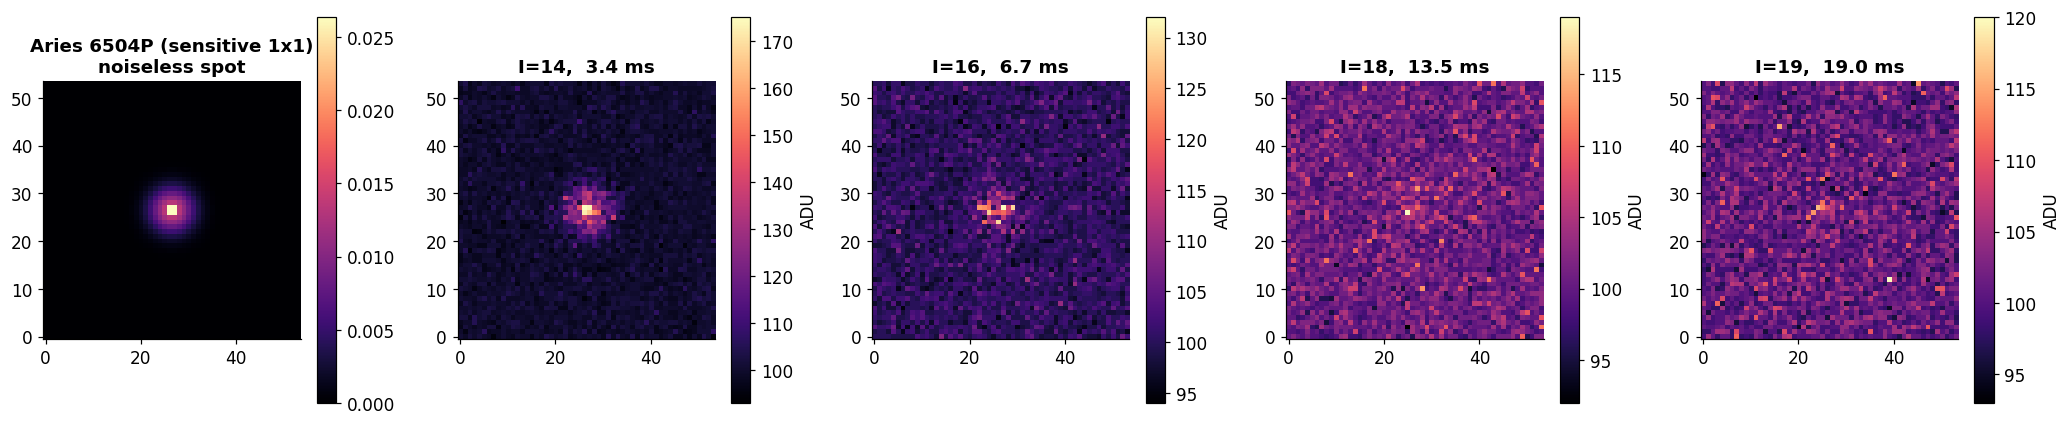

In [18]:
def tts_frame_rate(magnitude):
    """Smooth approximation to the STRAP magnitude/frame-rate schedule (Hz)."""
    return np.clip(1000.0 * 4.0 ** (-0.25 * (np.asarray(magnitude) - 10.5)), 25.0, 1000.0)


def bin_pattern(pattern, sampled):
    """Sum a native pattern into the mode's output super-pixels (noiseless)."""
    binning = sampled.detector_mode.binning
    height, width = sampled.output_shape
    return pattern.reshape(height, binning, width, binning).sum(axis=(1, 3))


def _tts_scene(pattern, plate_scale, magnitude, star_resp, sky_resp):
    """Detected star electron-rate map and per-pixel sky electron rate (TTS)."""
    star_rate = float(np.dot(incident_star_rates(magnitude), star_resp))
    photon_rate = pattern * star_rate * TTS_BEAMSPLITTER
    sky_rate = float(np.dot(incident_sky_rates(), sky_resp)) * TTS_BEAMSPLITTER * plate_scale**2
    return photon_rate, sky_rate


def expose_mode(sampled, photon_rate, exposure, sky_rate, seed):
    """Expose one native-pitch frame with the mode's binning (digital or on-chip)."""
    mode = sampled.detector_mode
    return sampled.camera.expose(
        photon_rate,
        exposure,
        background=sky_rate,
        quantum_efficiency=1.0,
        binning=mode.binning,
        binning_mode=mode.binning_method,
        seed=seed,
        include_truth=False,
    )


def _camera_aliases(candidate):
    """Names by which a preset may be selected in the walkthrough."""
    config = gf.load_preset(candidate.preset)
    aliases = {candidate.label, candidate.preset, config.name, config.model}
    # Also accept the model/name without a manufacturer prefix or suffix.
    for value in tuple(aliases):
        value = str(value).strip()
        aliases.add(value.split("(", 1)[0].strip())
        parts = value.split(maxsplit=1)
        if len(parts) == 2:
            aliases.add(parts[1])
    return {str(value).casefold() for value in aliases if str(value).strip()}


def first_mode_for(label, field_arcsec):
    """Return the first characterized mode for a camera name or preset."""
    modes = detector_modes(tuple(c for c in CANDIDATES if c.include))
    requested = str(label).strip().casefold()
    matches = [m for m in modes if requested in _camera_aliases(m.candidate)]
    if not matches:
        available = tuple(dict.fromkeys(m.candidate.label for m in modes))
        options = ", ".join(available) or "<none>"
        raise ValueError(f"Unknown detector camera {label!r}; choose one of: {options}")
    return sampled_mode(matches[0], field_arcsec)


demo = first_mode_for(TTS_EXAMPLE_CAMERA, TTS_FIELD_ARCSEC)
demo_star = band_response(demo.camera, NGS_SED)
demo_sky = band_response(demo.camera, SKY_WEIGHTING_SED)
demo_native = tts_spot(demo.native_shape, demo.native_plate_scale)
demo_output = bin_pattern(demo_native, demo)

fig, axes = plt.subplots(1, 5, figsize=(19, 4))
im = axes[0].imshow(demo_output, origin="lower")
axes[0].set_title(f"{demo.label}\nnoiseless spot")
fig.colorbar(im, ax=axes[0])
for ax, mag in zip(axes[1:], (14.0, 16.0, 18.0, 19.0)):
    photon_rate, sky_rate = _tts_scene(
        demo_native, demo.native_plate_scale, mag, demo_star, demo_sky
    )
    exposure = 1.0 / float(tts_frame_rate(mag))
    frame = expose_mode(demo, photon_rate, exposure, sky_rate, SEED + int(mag))
    im = ax.imshow(np.asarray(frame), origin="lower")
    ax.set_title(f"I={mag:.0f},  {exposure * 1e3:.1f} ms")
    fig.colorbar(im, ax=ax, label="ADU")
for ax in axes:
    ax.grid(False)
fig.tight_layout()

## 7. Calibration

We remove what the detector adds with no star: a short series of exposure-matched
sky+dark frames from `Camera.expose_series`, binned like science frames, reduced to
a **master background** (mean) and a **per-pixel noise σ map** (standard deviation,
scaled by `CENTROID_THRESHOLD_SIGMA` into the centroider's noise floor). The finite
master's own uncertainty is folded in as a `1 + 1/N` inflation.

master mean 100.8 ADU  |  median threshold 3.81 ADU


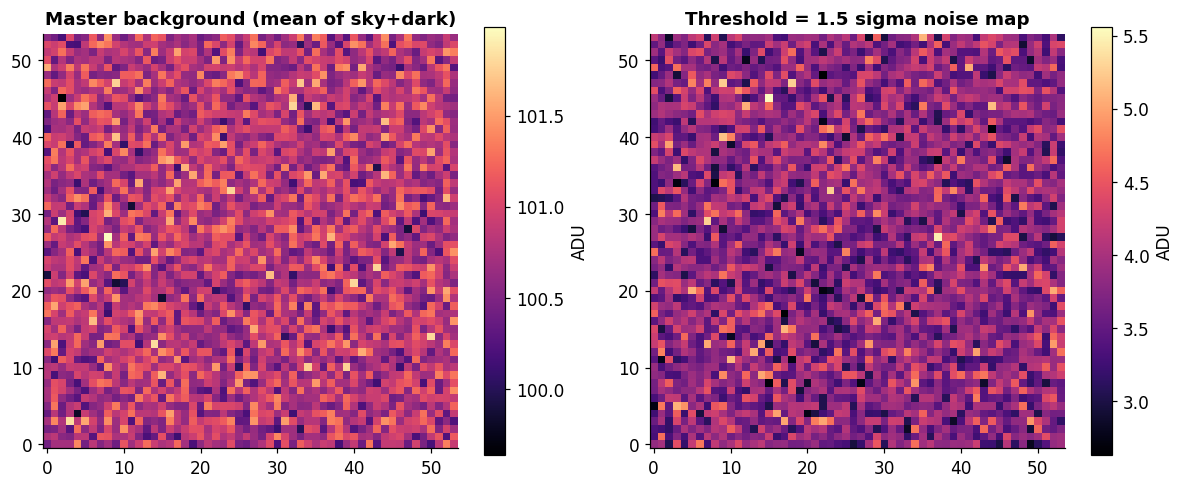

In [19]:
def master_background(sampled, sky_rate, exposure, calibration_frames, threshold_sigma, seed):
    """Exposure-matched sky+dark master and a per-pixel threshold map."""
    camera = sampled.camera
    mode = sampled.detector_mode
    zero = np.zeros(sampled.native_shape)
    series = camera.expose_series(
        zero,
        exposure,
        calibration_frames,
        background=sky_rate,
        quantum_efficiency=1.0,
        binning=mode.binning,
        binning_mode=mode.binning_method,
        seed=seed,
        include_truth=False,
    )
    stack = np.stack([np.asarray(frame, dtype=float) for frame in series])
    master = stack.mean(axis=0)
    variance = stack.var(axis=0, ddof=1)
    threshold = threshold_sigma * np.sqrt(variance * (1.0 + 1.0 / calibration_frames))
    return master, threshold


_, demo_sky_rate = _tts_scene(demo_native, demo.native_plate_scale, 18.0, demo_star, demo_sky)
demo_exposure = 1.0 / float(tts_frame_rate(18.0))
demo_master, demo_threshold = master_background(
    demo, demo_sky_rate, demo_exposure, CALIBRATION_FRAMES, CENTROID_THRESHOLD_SIGMA, SEED + 7
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, img, title in (
    (axes[0], demo_master, "Master background (mean of sky+dark)"),
    (axes[1], demo_threshold, f"Threshold = {CENTROID_THRESHOLD_SIGMA} sigma noise map"),
):
    im = ax.imshow(img, origin="lower")
    fig.colorbar(im, ax=ax, label="ADU")
    ax.set_title(title)
    ax.grid(False)
fig.tight_layout()
print(
    f"master mean {demo_master.mean():.1f} ADU  |  "
    f"median threshold {np.median(demo_threshold):.2f} ADU"
)

## 8. Centroiding

`getframes.analysis.centroid` takes the array master background and the per-pixel
threshold, subtracts both, clips negative weights, restricts to a tracking window,
and returns the first-moment centre of gravity:

```python
cx, cy = gf.analysis.centroid(binned, center=ref, r=radius,
                              background=master, threshold=threshold)
```

Below, one frame with a star at a known sub-pixel offset. The image shown is
**calibrated** (master subtracted, so the background sits near zero, not at the
~100 ADU bias pedestal). The dashed circle is the fixed centroiding window; the
markers are the true position and the measured centroid.

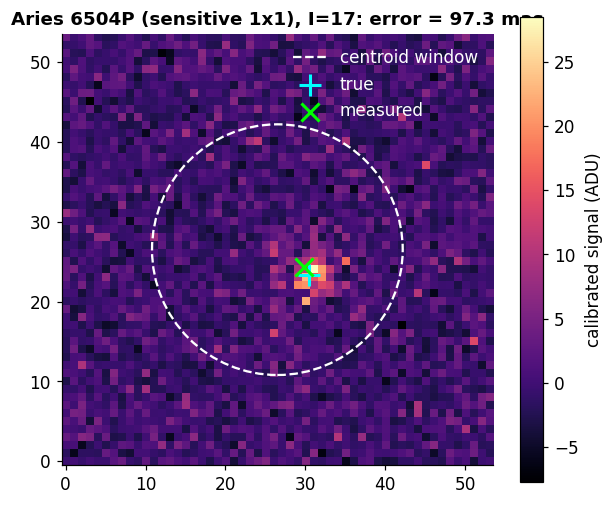

In [20]:
def _tracking_window_radius(plate_scale, field_arcsec, walk_arcsec):
    """Fixed CoG window large enough for the tested walk and seeing footprint."""
    required = walk_arcsec * np.sqrt(2.0) + seeing_fwhm_arcsec() / 2.0
    return min(required / plate_scale, field_arcsec / (2.0 * plate_scale))


TTS_TRACKING_WALK_ARCSEC = 0.75
ref_center = gf.analysis.centroid(demo_output, background=0.0)
radius = _tracking_window_radius(
    demo.output_plate_scale, TTS_FIELD_ARCSEC, TTS_TRACKING_WALK_ARCSEC
)

offset = (0.35, -0.28)  # arcsec
photon_rate, sky_rate = _tts_scene(
    tts_spot(demo.native_shape, demo.native_plate_scale, offset),
    demo.native_plate_scale,
    17.0,
    demo_star,
    demo_sky,
)
frame = expose_mode(demo, photon_rate, demo_exposure, sky_rate, SEED + 123)
cx, cy = gf.analysis.centroid(
    frame, center=ref_center, r=radius, background=demo_master, threshold=demo_threshold
)
calibrated = np.asarray(frame) - demo_master
true_x = ref_center[0] + offset[0] / demo.output_plate_scale
true_y = ref_center[1] + offset[1] / demo.output_plate_scale
error_mas = 1000.0 * np.hypot(cx - true_x, cy - true_y) * demo.output_plate_scale

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(calibrated, origin="lower")
fig.colorbar(im, ax=ax, label="calibrated signal (ADU)")
ax.plot([], [], ls="--", color="white", label="centroid window")
ax.add_patch(plt.Circle(ref_center, radius, fill=False, ls="--", ec="white", lw=1.5))
ax.scatter(true_x, true_y, marker="+", s=200, c="cyan", lw=2, label="true")
ax.scatter(cx, cy, marker="x", s=140, c="lime", lw=2, label="measured")
ax.set(title=f"{demo.label}, I=17: error = {error_mas:.1f} mas")
ax.legend(
    loc="upper right", facecolor="0.15", edgecolor="white", labelcolor="white", framealpha=0.85
)
ax.grid(False)
fig.tight_layout()

## 9. Centroid error vs magnitude

The metric is the RMS over many frames and many spot positions. We lay
`MOTION_POSITIONS` stratified positions across a ±0.75 arcsec tracking walk, build
the spot at each, simulate `TRIALS` noise realisations, centroid each, and report
the radial RMS split into bias and random σ, with a Monte Carlo standard error.

The grid below makes the curve concrete for `TTS_EXAMPLE_CAMERA`: **rows are
magnitudes**, **columns are spot positions**, each a calibrated frame with the true
(+) and measured (×) centroids. The star is bright and well-centred at the top,
noisy and mis-centred at the bottom.

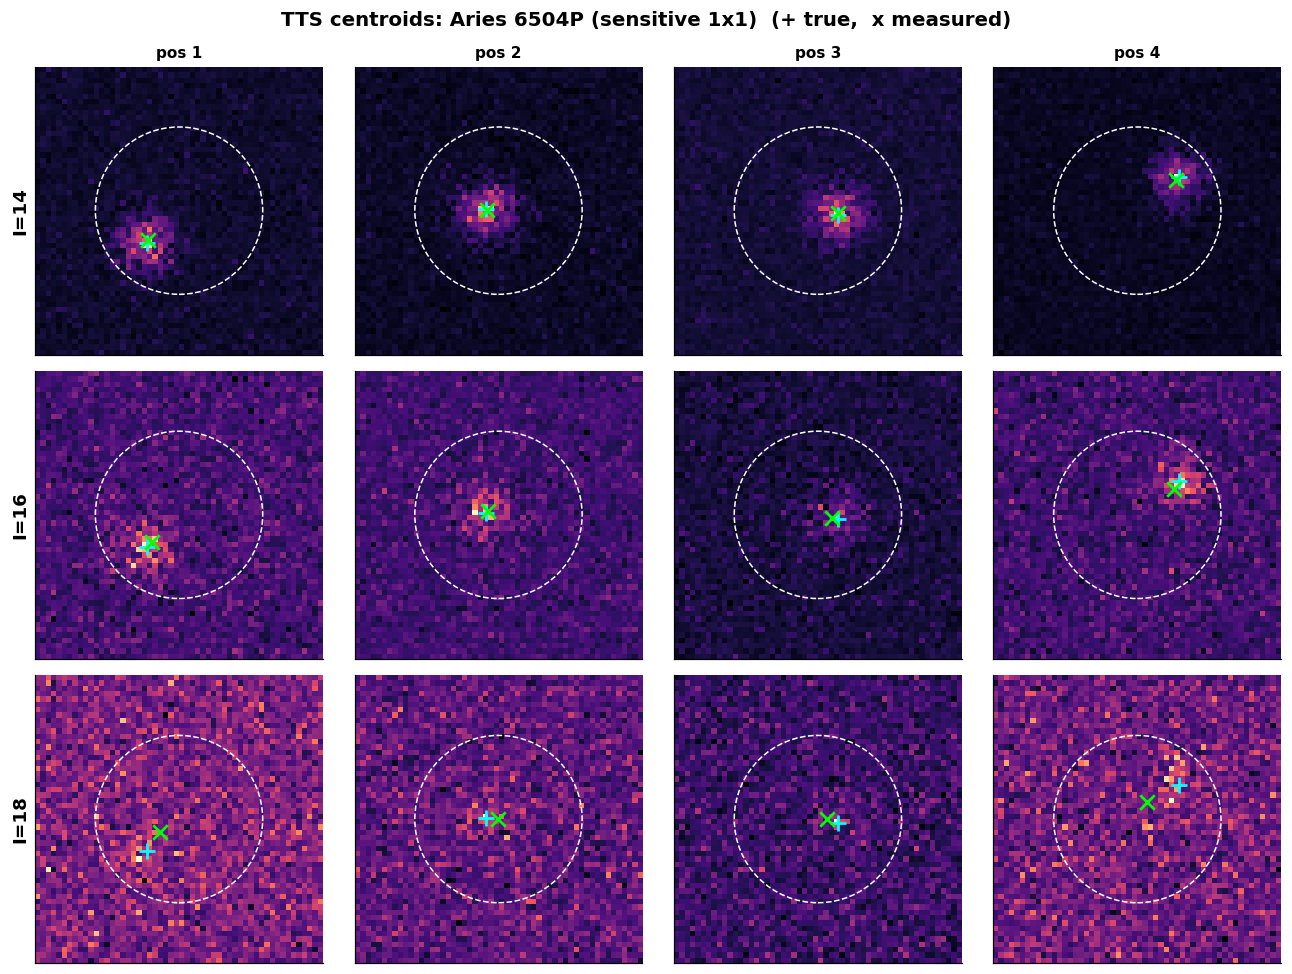

In [21]:
def _motion_offsets(positions, half_range_arcsec, seed):
    """Stratified spot positions across a square tracking walk (arcsec)."""
    rng = np.random.default_rng(np.random.SeedSequence([seed, 701]))
    unit_x = (np.arange(positions) + rng.random(positions)) / positions
    unit_y = (rng.permutation(np.arange(positions)) + rng.random(positions)) / positions
    return np.column_stack((2.0 * unit_x - 1.0, 2.0 * unit_y - 1.0)) * half_range_arcsec


MOTION_POSITION_SEED = 941


def centroid_example_grid(
    sampled,
    spot_fn,
    scene_fn,
    exposure_fn,
    field_arcsec,
    walk,
    magnitudes,
    n_positions,
    seed,
    title,
):
    """Grid of calibrated example frames: rows = magnitudes, cols = spot positions."""
    star_resp = band_response(sampled.camera, NGS_SED)
    sky_resp = band_response(sampled.camera, SKY_WEIGHTING_SED)
    output0 = bin_pattern(
        spot_fn(sampled.native_shape, sampled.native_plate_scale, (0.0, 0.0)), sampled
    )
    ref = gf.analysis.centroid(output0, background=0.0)
    radius = _tracking_window_radius(sampled.output_plate_scale, field_arcsec, walk)
    offsets = _motion_offsets(n_positions, walk, MOTION_POSITION_SEED)[:n_positions]
    ext = _extent(sampled.output_shape, sampled.output_plate_scale)

    fig, axes = plt.subplots(
        len(magnitudes), n_positions, figsize=(3.0 * n_positions, 3.0 * len(magnitudes))
    )
    axes = np.atleast_2d(axes)
    for i, mag in enumerate(magnitudes):
        exposure = exposure_fn(mag)
        _, sky_rate = scene_fn(
            spot_fn(sampled.native_shape, sampled.native_plate_scale, (0.0, 0.0)),
            sampled.native_plate_scale,
            mag,
            star_resp,
            sky_resp,
        )
        master, threshold = master_background(
            sampled,
            sky_rate,
            exposure,
            CALIBRATION_FRAMES,
            CENTROID_THRESHOLD_SIGMA,
            seed + 5000 * i,
        )
        for j in range(n_positions):
            off = offsets[j]
            pat = spot_fn(
                sampled.native_shape, sampled.native_plate_scale, (float(off[0]), float(off[1]))
            )
            photon_rate, _ = scene_fn(pat, sampled.native_plate_scale, mag, star_resp, sky_resp)
            frame = expose_mode(sampled, photon_rate, exposure, sky_rate, seed + 5000 * i + j + 1)
            cx, cy = gf.analysis.centroid(
                frame, center=ref, r=radius, background=master, threshold=threshold
            )
            ax = axes[i, j]
            ax.imshow(np.asarray(frame) - master, origin="lower", extent=ext)
            ax.add_patch(
                plt.Circle(
                    (0.0, 0.0),
                    radius * sampled.output_plate_scale,
                    fill=False,
                    ls="--",
                    ec="white",
                    lw=1,
                )
            )
            scx = (cx - ref[0]) * sampled.output_plate_scale
            scy = (cy - ref[1]) * sampled.output_plate_scale
            ax.scatter(off[0], off[1], marker="+", s=120, c="cyan", lw=1.8)
            ax.scatter(scx, scy, marker="x", s=90, c="lime", lw=1.8)
            ax.grid(False)
            ax.set_xticks([])
            ax.set_yticks([])
            if j == 0:
                ax.set_ylabel(f"I={mag:.0f}", fontsize=12, fontweight="bold")
            if i == 0:
                ax.set_title(f"pos {j + 1}", fontsize=10)
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    return fig


_ = centroid_example_grid(
    demo,
    tts_spot,
    _tts_scene,
    lambda m: 1.0 / float(tts_frame_rate(m)),
    TTS_FIELD_ARCSEC,
    TTS_TRACKING_WALK_ARCSEC,
    EXAMPLE_MAGNITUDES,
    4,
    SEED + 4242,
    f"TTS centroids: {demo.label}  (+ true,  x measured)",
)

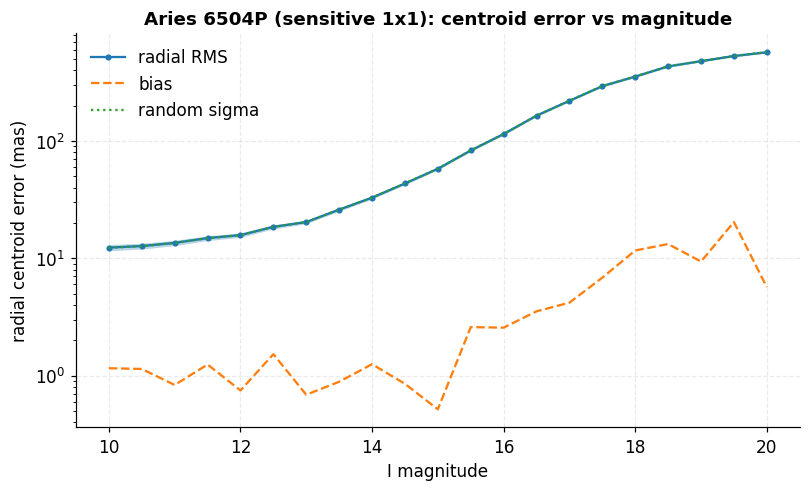

In [22]:
def _rms_and_error(squared, scale):
    """RMS sqrt(mean(squared)) and its standard error, scaled to arcsec."""
    rms = float(np.sqrt(np.mean(squared)))
    if rms == 0.0:
        return 0.0, 0.0
    se = float(np.std(squared, ddof=1) / (2.0 * rms * np.sqrt(squared.size)))
    return rms * scale, se * scale


@dataclass(frozen=True)
class CentroidMoments:
    radial_rms: float
    radial_rms_se: float
    bias: float
    random_sigma: float


def _centroid_moments(dx, dy, scale):
    rms, se = _rms_and_error(dx**2 + dy**2, scale)
    bias = float(np.hypot(np.mean(dx), np.mean(dy)) * scale)
    random_sigma = float(np.sqrt(np.var(dx, ddof=1) + np.var(dy, ddof=1)) * scale)
    return CentroidMoments(rms, se, bias, random_sigma)


def tts_rms_error(sampled, magnitude, exposure, star_resp, sky_resp, trials, seed):
    """Radial centroid moments for a moving TTS spot using the calibrated CoG."""
    output0 = bin_pattern(tts_spot(sampled.native_shape, sampled.native_plate_scale), sampled)
    ref = gf.analysis.centroid(output0, background=0.0)
    radius = _tracking_window_radius(
        sampled.output_plate_scale, TTS_FIELD_ARCSEC, TTS_TRACKING_WALK_ARCSEC
    )
    native0 = tts_spot(sampled.native_shape, sampled.native_plate_scale)
    _, sky_rate = _tts_scene(native0, sampled.native_plate_scale, magnitude, star_resp, sky_resp)
    master, threshold = master_background(
        sampled, sky_rate, exposure, CALIBRATION_FRAMES, CENTROID_THRESHOLD_SIGMA, seed + 500_000
    )
    offsets = _motion_offsets(MOTION_POSITIONS, TTS_TRACKING_WALK_ARCSEC, MOTION_POSITION_SEED)
    patterns = [
        tts_spot(sampled.native_shape, sampled.native_plate_scale, (float(dx), float(dy)))
        for dx, dy in offsets
    ]
    dx_err = np.empty(trials)
    dy_err = np.empty(trials)
    frame_seeds = np.random.SeedSequence([seed, 702]).generate_state(trials, dtype=np.uint64)
    for t, fs in enumerate(frame_seeds):
        pos = offsets[t % MOTION_POSITIONS]
        photon_rate, _ = _tts_scene(
            patterns[t % MOTION_POSITIONS],
            sampled.native_plate_scale,
            magnitude,
            star_resp,
            sky_resp,
        )
        frame = expose_mode(sampled, photon_rate, exposure, sky_rate, int(fs))
        cx, cy = gf.analysis.centroid(
            frame, center=ref, r=radius, background=master, threshold=threshold
        )
        dx_err[t] = cx - (ref[0] + pos[0] / sampled.output_plate_scale)
        dy_err[t] = cy - (ref[1] + pos[1] / sampled.output_plate_scale)
    return _centroid_moments(dx_err, dy_err, sampled.output_plate_scale)


def tts_centroid_error(sampled, magnitudes, trials, seed):
    """TTS centroid RMS curve on the STRAP cadence schedule."""
    star_resp = band_response(sampled.camera, NGS_SED)
    sky_resp = band_response(sampled.camera, SKY_WEIGHTING_SED)
    return [
        tts_rms_error(
            sampled,
            float(mag),
            1.0 / float(tts_frame_rate(float(mag))),
            star_resp,
            sky_resp,
            trials,
            seed + 10_000 * i,
        )
        for i, mag in enumerate(magnitudes)
    ]


demo_curve = tts_centroid_error(demo, MAGNITUDES, TRIALS, SEED)
rms = 1000.0 * np.array([m.radial_rms for m in demo_curve])
se = 1000.0 * np.array([m.radial_rms_se for m in demo_curve])
bias = 1000.0 * np.array([m.bias for m in demo_curve])
sigma = 1000.0 * np.array([m.random_sigma for m in demo_curve])

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(MAGNITUDES, rms, "-o", ms=3, color=COLORS[0], label="radial RMS")
ax.fill_between(MAGNITUDES, rms - se, rms + se, color=COLORS[0], alpha=0.3, lw=0)
ax.plot(MAGNITUDES, bias, "--", color=COLORS[1], label="bias")
ax.plot(MAGNITUDES, sigma, ":", color=COLORS[2], label="random sigma")
ax.set(
    title=f"{demo.label}: centroid error vs magnitude",
    xlabel="I magnitude",
    ylabel="radial centroid error (mas)",
    yscale="log",
)
ax.legend()
fig.tight_layout()

## 10. The tip/tilt trade

Every characterized mode across the magnitude grid, plus STRAP as the incumbent,
keeping the best characterized mode per camera at I=18.

In [23]:
def reference_sample(label, camera, plate_scale, shape):
    """Wrap an incumbent camera in the same SampledMode interface (binning 1)."""
    cand = DetectorCandidate("reference", label)
    mode = DetectorMode(
        cand,
        "native",
        1,
        "digital",
        camera.config.read_noise_e,
        camera.config.dark_current_e_per_s,
        camera.default_temperature_c,
    )
    configured = gf.Camera(
        camera.config.replace(resolution=shape), default_temperature_c=camera.default_temperature_c
    )
    return SampledMode(mode, configured, plate_scale, plate_scale, shape, shape)


def strap_camera():
    return gf.Camera(
        gf.CameraConfig(
            name="Keck STRAP quad cell",
            sensor_type="CCD",
            resolution=(2, 2),
            pixel_size_um=1.0,
            quantum_efficiency=0.50,
            full_well_e=1e8,
            bit_depth=24,
            gain_e_per_adu=1.0,
            bias_offset_adu=100.0,
            read_noise_e=0.0,
            dark_current_e_per_s=0.0,
        )
    )


def little_joe_camera():
    config = gf.load_preset("scimeasure_little_joe_ccd39").replace(
        name="Keck Little Joe CCD39", read_noise_e=8.0, dark_current_e_per_s=5.0
    )
    return gf.Camera(config, default_temperature_c=-40.0)


def select_best_mode(samples, results, magnitudes, reference_mag):
    """Lowest-RMS characterized mode per detector at one magnitude."""
    idx = int(np.argmin(np.abs(magnitudes - reference_mag)))
    best = {}
    for s in samples:
        label = s.detector_mode.candidate.label
        rms = results[s.label][idx].radial_rms
        if label not in best or rms < results[best[label].label][idx].radial_rms:
            best[label] = s
    return best


# Simulate every characterized mode for the TTS.
tts_samples = tuple(sampled_mode(m, TTS_FIELD_ARCSEC) for m in modes)
tts_results = {}
for i, s in enumerate(tts_samples):
    print(f"  TTS: {s.label}")
    tts_results[s.label] = tts_centroid_error(s, MAGNITUDES, TRIALS, SEED + 1_000_000 * i)
tts_best = select_best_mode(tts_samples, tts_results, MAGNITUDES, 18.0)

strap = reference_sample("STRAP", strap_camera(), 1.4, (2, 2))
print("  TTS ref: STRAP")
tts_results["STRAP (native)"] = tts_centroid_error(strap, MAGNITUDES, TRIALS, SEED + 100_000_000)
strap_key = "STRAP (native)"
tts_display = {"STRAP": strap, **tts_best}
tts_result_key = {"STRAP": strap_key, **{lbl: s.label for lbl, s in tts_best.items()}}

  TTS: Marana-11 (1x1)
  TTS: Marana-11 (2x2)
  TTS: Marana-11 (3x3)
  TTS: Marana-11 (4x4)
  TTS: Marana-11 (8x8)
  TTS: KURO 1200B (1x1)
  TTS: KURO 1200B (2x2)
  TTS: KURO 1200B (4x4)
  TTS: Prime 95B (1x1)
  TTS: Prime 95B (2x2)
  TTS: QHY530 (1x1)
  TTS: QHY530 (2x2)
  TTS: Aries 6504P (sensitive 1x1)
  TTS: Aries 6504P (sensitive 2x2)
  TTS: Aries 6504P (sensitive 4x4)
  TTS: Aries 6504P (speed 1x1)
  TTS: ORCA-Quest 2 (standard 1x1)
  TTS: ORCA-Quest 2 (standard 2x2)
  TTS: ORCA-Quest 2 (standard 4x4)
  TTS: ORCA-Quest 2 (ultra quiet 1x1)
  TTS: ORCA-Quest 2 (ultra quiet 2x2)
  TTS: ORCA-Quest 2 (ultra quiet 4x4)
  TTS: CB1 0.5 MP (1x1)
  TTS ref: STRAP


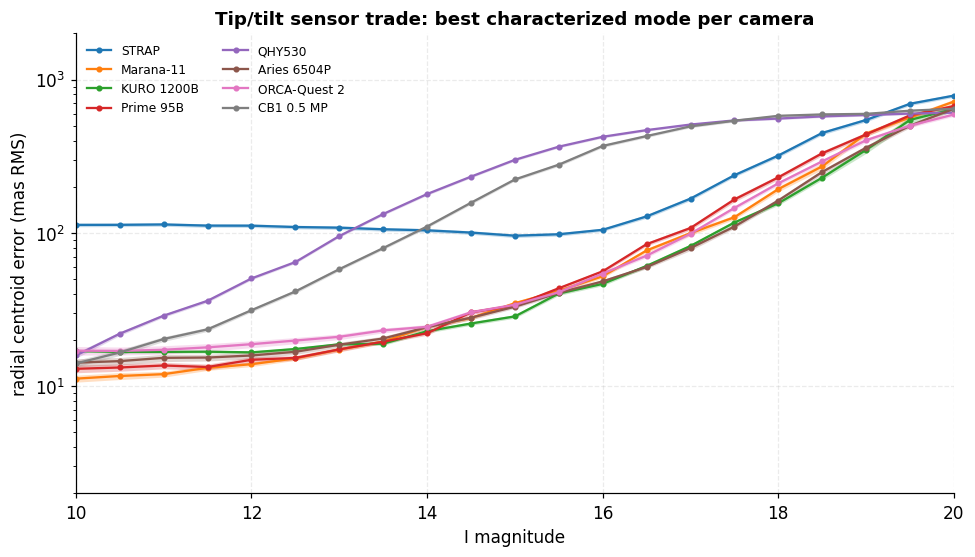

In [24]:
fig, ax = plt.subplots(figsize=(9, 5.2))
for i, (label, key) in enumerate(tts_result_key.items()):
    curve = tts_results[key]
    rms = 1000.0 * np.array([m.radial_rms for m in curve])
    se = 1000.0 * np.array([m.radial_rms_se for m in curve])
    ax.plot(MAGNITUDES, rms, "-o", ms=3, color=COLORS[i % 10], label=label)
    ax.fill_between(MAGNITUDES, rms - se, rms + se, color=COLORS[i % 10], alpha=0.25, lw=0)
ax.set(
    title="Tip/tilt sensor trade: best characterized mode per camera",
    xlabel="I magnitude",
    ylabel="radial centroid error (mas RMS)",
    xlim=(10, 20),
    ylim=(2, 2000),
    yscale="log",
)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()

## 11. The low-bandwidth WFS trade

The same pipeline on a Shack–Hartmann sub-aperture spot, with the light split the
other way (10% of the beam, divided among the sub-apertures) and its own
integration-time schedule. We compare the sparse 20×20 and the coarser 5×5 (which
concentrates the light into fewer, brighter spots). Little Joe is the incumbent.
First, the same per-magnitude centroid grid for `LBWFS_EXAMPLE_CAMERA`.

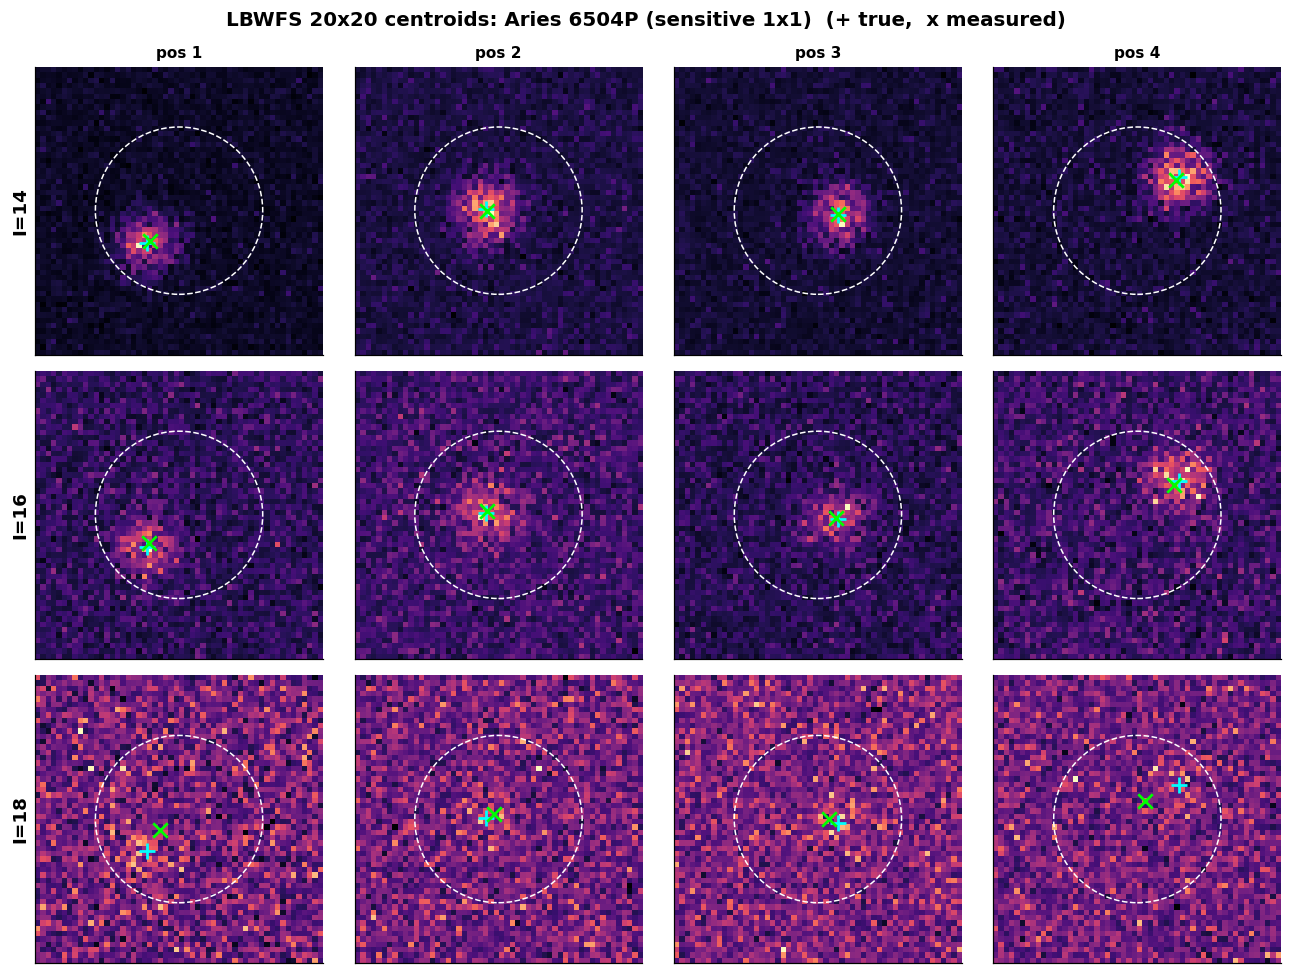

In [25]:
LBWFS_TRACKING_WALK_ARCSEC = 0.75


def lbwfs_integration(magnitude):
    """Smooth approximation to the LBWFS magnitude/integration-time table (s)."""
    return np.clip(2.0 ** (np.asarray(magnitude) - 10.5), 1.0, 60.0)


def _lbwfs_scene(pattern, plate_scale, magnitude, star_resp, sky_resp, mode=20):
    subap = 304 if mode == 20 else 20
    star_rate = float(np.dot(incident_star_rates(magnitude), star_resp))
    photon_rate = pattern * star_rate * (1.0 - TTS_BEAMSPLITTER) / subap
    sky = float(np.dot(incident_sky_rates(), sky_resp))
    sky_rate = sky * (1.0 - TTS_BEAMSPLITTER) * plate_scale**2 / subap
    return photon_rate, sky_rate


lbwfs_demo = first_mode_for(LBWFS_EXAMPLE_CAMERA, LBWFS_FIELD_ARCSEC)
_ = centroid_example_grid(
    lbwfs_demo,
    lambda shape, scale, off=(0.0, 0.0): lbwfs_spot(20, shape, scale, off),
    lambda pat, scale, mag, sr, kr: _lbwfs_scene(pat, scale, mag, sr, kr, mode=20),
    lambda m: float(lbwfs_integration(m)),
    LBWFS_FIELD_ARCSEC,
    LBWFS_TRACKING_WALK_ARCSEC,
    EXAMPLE_MAGNITUDES,
    4,
    SEED + 8484,
    f"LBWFS 20x20 centroids: {lbwfs_demo.label}  (+ true,  x measured)",
)

In [26]:
def lbwfs_centroid_error(sampled, magnitudes, mode, trials, seed):
    """LBWFS calibrated-CoG RMS curve for a moving sub-aperture spot."""
    output0 = bin_pattern(
        lbwfs_spot(mode, sampled.native_shape, sampled.native_plate_scale), sampled
    )
    ref = gf.analysis.centroid(output0, background=0.0)
    radius = _tracking_window_radius(
        sampled.output_plate_scale, LBWFS_FIELD_ARCSEC, LBWFS_TRACKING_WALK_ARCSEC
    )
    star_resp = band_response(sampled.camera, NGS_SED)
    sky_resp = band_response(sampled.camera, SKY_WEIGHTING_SED)
    out = []
    for i, mag in enumerate(magnitudes):
        schedule_mag = float(mag) if mode == 20 else float(mag) - 1.5
        exposure = float(lbwfs_integration(schedule_mag))
        native0 = lbwfs_spot(mode, sampled.native_shape, sampled.native_plate_scale)
        _, sky_rate = _lbwfs_scene(
            native0, sampled.native_plate_scale, float(mag), star_resp, sky_resp, mode=mode
        )
        master, threshold = master_background(
            sampled,
            sky_rate,
            exposure,
            CALIBRATION_FRAMES,
            CENTROID_THRESHOLD_SIGMA,
            seed + 500_000 + 10_000 * i,
        )
        offsets = _motion_offsets(
            MOTION_POSITIONS, LBWFS_TRACKING_WALK_ARCSEC, MOTION_POSITION_SEED
        )
        patterns = [
            lbwfs_spot(
                mode, sampled.native_shape, sampled.native_plate_scale, (float(dx), float(dy))
            )
            for dx, dy in offsets
        ]
        dx_err = np.empty(trials)
        dy_err = np.empty(trials)
        fseeds = np.random.SeedSequence([seed + 10_000 * i, 703]).generate_state(trials, np.uint64)
        for t, fs in enumerate(fseeds):
            pos = offsets[t % MOTION_POSITIONS]
            photon_rate, _ = _lbwfs_scene(
                patterns[t % MOTION_POSITIONS],
                sampled.native_plate_scale,
                float(mag),
                star_resp,
                sky_resp,
                mode=mode,
            )
            frame = expose_mode(sampled, photon_rate, exposure, sky_rate, int(fs))
            cx, cy = gf.analysis.centroid(
                frame, center=ref, r=radius, background=master, threshold=threshold
            )
            dx_err[t] = cx - (ref[0] + pos[0] / sampled.output_plate_scale)
            dy_err[t] = cy - (ref[1] + pos[1] / sampled.output_plate_scale)
        out.append(_centroid_moments(dx_err, dy_err, sampled.output_plate_scale))
    return out


def run_lbwfs(mode, seed_base):
    samples = tuple(sampled_mode(m, LBWFS_FIELD_ARCSEC) for m in modes)
    results = {}
    for i, s in enumerate(samples):
        print(f"  LBWFS {mode}x{mode}: {s.label}")
        results[s.label] = lbwfs_centroid_error(
            s, MAGNITUDES, mode, TRIALS, seed_base + 1_000_000 * i
        )
    best = select_best_mode(samples, results, MAGNITUDES, 17.0)
    lj_scale = 24.0 * TTS_ARCSEC_PER_MM / 1000.0
    lj = reference_sample(
        "Little Joe", little_joe_camera(), lj_scale, shape_for_field(LBWFS_FIELD_ARCSEC, lj_scale)
    )
    print(f"  LBWFS {mode}x{mode} ref: Little Joe")
    results["Little Joe (native)"] = lbwfs_centroid_error(
        lj, MAGNITUDES, mode, TRIALS, seed_base + 200_000_000
    )
    display = {"Little Joe": lj, **best}
    result_key = {"Little Joe": "Little Joe (native)", **{lbl: s.label for lbl, s in best.items()}}
    return display, results, best, result_key


lbwfs20_display, lbwfs20_results, lbwfs20_best, lbwfs20_key = run_lbwfs(20, SEED + 10_000_000)
lbwfs5_display, lbwfs5_results, lbwfs5_best, lbwfs5_key = run_lbwfs(5, SEED + 20_000_000)

  LBWFS 20x20: Marana-11 (1x1)
  LBWFS 20x20: Marana-11 (2x2)
  LBWFS 20x20: Marana-11 (3x3)
  LBWFS 20x20: Marana-11 (4x4)
  LBWFS 20x20: Marana-11 (8x8)
  LBWFS 20x20: KURO 1200B (1x1)
  LBWFS 20x20: KURO 1200B (2x2)
  LBWFS 20x20: KURO 1200B (4x4)
  LBWFS 20x20: Prime 95B (1x1)
  LBWFS 20x20: Prime 95B (2x2)
  LBWFS 20x20: QHY530 (1x1)
  LBWFS 20x20: QHY530 (2x2)
  LBWFS 20x20: Aries 6504P (sensitive 1x1)
  LBWFS 20x20: Aries 6504P (sensitive 2x2)
  LBWFS 20x20: Aries 6504P (sensitive 4x4)
  LBWFS 20x20: Aries 6504P (speed 1x1)
  LBWFS 20x20: ORCA-Quest 2 (standard 1x1)
  LBWFS 20x20: ORCA-Quest 2 (standard 2x2)
  LBWFS 20x20: ORCA-Quest 2 (standard 4x4)
  LBWFS 20x20: ORCA-Quest 2 (ultra quiet 1x1)
  LBWFS 20x20: ORCA-Quest 2 (ultra quiet 2x2)
  LBWFS 20x20: ORCA-Quest 2 (ultra quiet 4x4)
  LBWFS 20x20: CB1 0.5 MP (1x1)
  LBWFS 20x20 ref: Little Joe
  LBWFS 5x5: Marana-11 (1x1)
  LBWFS 5x5: Marana-11 (2x2)
  LBWFS 5x5: Marana-11 (3x3)
  LBWFS 5x5: Marana-11 (4x4)
  LBWFS 5x5: Maran

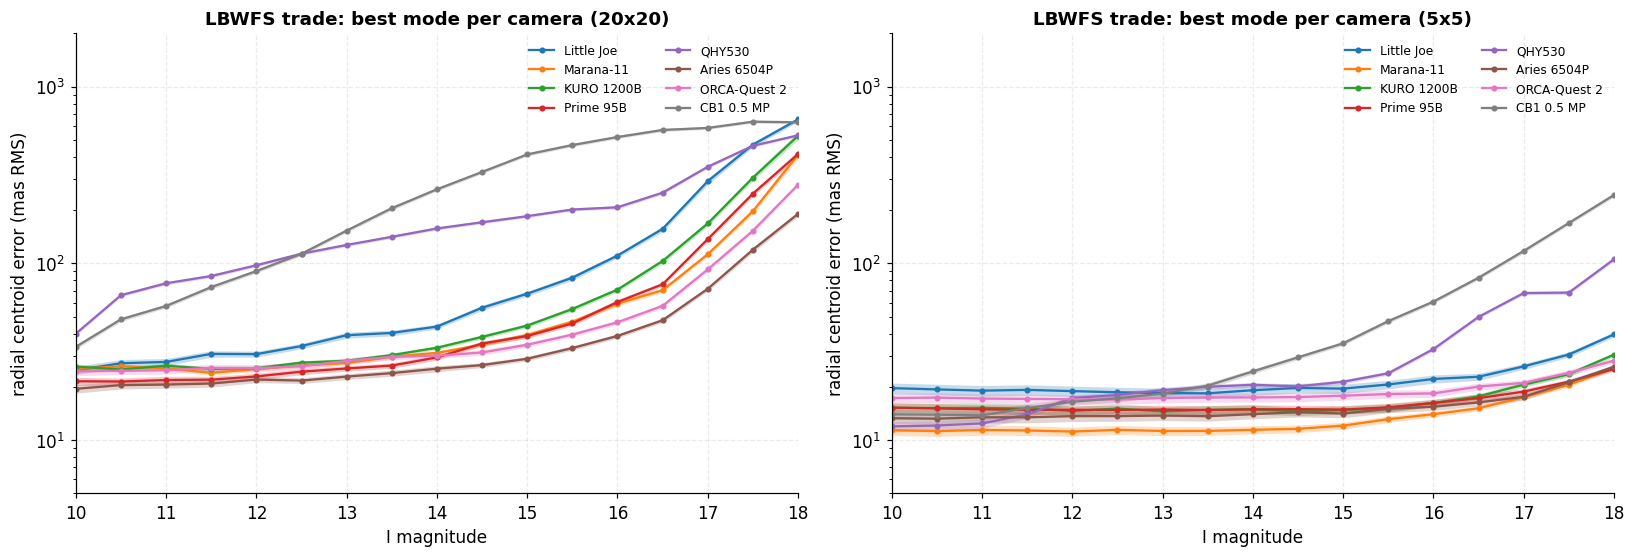

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, results, keymap, title in (
    (axes[0], lbwfs20_results, lbwfs20_key, "LBWFS trade: best mode per camera (20x20)"),
    (axes[1], lbwfs5_results, lbwfs5_key, "LBWFS trade: best mode per camera (5x5)"),
):
    for i, (label, key) in enumerate(keymap.items()):
        curve = results[key]
        rms = 1000.0 * np.array([m.radial_rms for m in curve])
        se = 1000.0 * np.array([m.radial_rms_se for m in curve])
        ax.plot(MAGNITUDES, rms, "-o", ms=3, color=COLORS[i % 10], label=label)
        ax.fill_between(MAGNITUDES, rms - se, rms + se, color=COLORS[i % 10], alpha=0.25, lw=0)
    ax.set(
        title=title,
        xlabel="I magnitude",
        ylabel="radial centroid error (mas RMS)",
        xlim=(10, 18),
        ylim=(5, 2000),
        yscale="log",
    )
    ax.legend(ncol=2, fontsize=8)
fig.tight_layout()

## 12. The pick

Reference-magnitude tables: the selected mode per camera, its modelled output read
noise, and its centroid error against the incumbent. The winner of each trade is the
lowest-error realizable camera at the reference magnitude (I=18 for the TTS, I=17 for
the LBWFS) — the detector we would put behind the f/1.45 relay.

In [28]:
def report(title, display, results, keymap, reference_mag):
    idx = int(np.argmin(np.abs(MAGNITUDES - reference_mag)))
    print(f"\n{title}  (I={MAGNITUDES[idx]:.0f})")
    print(f"  {'camera':<16}{'selected mode':<26}{'scale':>9}{'read noise':>13}{'RMS':>12}")
    ranking = sorted(keymap.items(), key=lambda kv: results[kv[1]][idx].radial_rms)
    incumbents = {"STRAP", "Little Joe"}
    best_realizable = next(label for label, _ in ranking if label not in incumbents)
    for label, key in ranking:
        s = display[label]
        m = s.detector_mode
        rn = m.read_noise_e * m.binning if m.binning_method == "digital" else m.read_noise_e
        rms = 1000.0 * results[key][idx].radial_rms
        tag = "  <-- best realizable" if label == best_realizable else ""
        print(
            f'  {label:<16}{m.name:<26}{s.output_plate_scale:7.3f}"{rn:9.2f} e-{rms:9.1f} mas{tag}'
        )


report("TIP/TILT SENSOR", tts_display, tts_results, tts_result_key, 18.0)
report("LBWFS 20x20", lbwfs20_display, lbwfs20_results, lbwfs20_key, 17.0)
report("LBWFS 5x5", lbwfs5_display, lbwfs5_results, lbwfs5_key, 17.0)


TIP/TILT SENSOR  (I=18)
  camera          selected mode                 scale   read noise         RMS
  KURO 1200B      4x4                         0.603"     5.20 e-    156.0 mas  <-- best realizable
  Aries 6504P     sensitive 4x4               0.356"     1.72 e-    162.5 mas
  Marana-11       3x3                         0.452"     4.80 e-    192.9 mas
  ORCA-Quest 2    ultra quiet 4x4             0.252"     1.20 e-    210.5 mas
  Prime 95B       2x2                         0.301"     3.60 e-    230.2 mas
  STRAP           native                      1.400"     0.00 e-    319.6 mas
  QHY530          2x2                         0.075"     1.17 e-    556.9 mas
  CB1 0.5 MP      1x1                         0.123"     2.35 e-    580.1 mas

LBWFS 20x20  (I=17)
  camera          selected mode                 scale   read noise         RMS
  Aries 6504P     sensitive 4x4               0.356"     1.72 e-     71.8 mas  <-- best realizable
  ORCA-Quest 2    ultra quiet 4x4             0.252"